# ⭐ Day 69: Tabular Deep Learning  
## Neural Networks for Tabular Data (TabNet, FT-Transformer & More)  
**🐍 Python & AI Learning Path | Day 69 / 369**

## 📋 Table of Contents

1. [Why Deep Learning for Tabular Data?](#1.-why-deep-learning-for-tabular-data)
2. [Challenges of Applying Standard Neural Networks to Tabular Data](#2.-challenges-of-applying-standard-neural-networks-to-tabular-data)
3. [Modern Tabular Deep Learning Architectures](#3.-modern-tabular-deep-learning-architectures)
4. [Installing and Using TabNet](#4.-installing-and-using-tabnet)
5. [Training TabNet on Titanic Dataset](#5.-training-tabnet-on-titanic-dataset)
6. [Installing and Using FT-Transformer](#6.-installing-and-using-ft-transformer)
7. [Training FT-Transformer and Comparison](#7.-training-ft-transformer-and-comparison)
8. [Hyperparameter Tuning for Tabular Neural Networks](#8.-hyperparameter-tuning-for-tabular-neural-networks)
9. [Performance Comparison: XGBoost vs LightGBM vs TabNet vs FT-Transformer](#9.-performance-comparison-xgboost-vs-lightgbm-vs-tabnet-vs-ft-transformer)
10. [When to Use Tabular Deep Learning vs Gradient Boosting](#10.-when-to-use-tabular-deep-learning-vs-gradient-boosting)
11. [🛠️ Hands-On Exercises](#-hands-on-exercises)
12. [Solutions & Key Insights](#solutions--key-insights)


## 🧠 Introduction

For decades, tabular data has been the undisputed kingdom of gradient boosting machines. XGBoost, LightGBM, and CatBoost have dominated Kaggle competitions, enterprise machine learning pipelines, and academic benchmarks alike. Their ability to handle heterogeneous features, missing values, and non-linear interactions with minimal preprocessing has made them the go-to choice for data scientists worldwide. If you've worked on any real-world ML problem involving spreadsheets, databases, or CSV files, you've almost certainly reached for one of these powerful algorithms.

However, the deep learning revolution that transformed computer vision and natural language processing is now making significant inroads into tabular territory. A new generation of neural network architectures — specifically engineered for the unique challenges of structured data — is challenging the hegemony of tree-based models. These aren't your standard multi-layer perceptrons with a few dense layers slapped together. Instead, they incorporate attention mechanisms, transformer blocks, and novel embedding strategies that learn rich representations from categorical and numerical features alike.

Today, on Day 69 of our 369-day journey, we dive deep into the cutting edge of tabular deep learning. We'll explore **TabNet**, which uses sequential attention to mimic the decision-making process of tree ensembles while maintaining differentiability. We'll examine the **FT-Transformer** (Feature Tokenizer + Transformer), which applies the mighty transformer architecture — the same technology powering GPT and BERT — directly to tabular data. We'll also briefly survey other notable architectures like NODE, DANet, and SAINT that are pushing the boundaries of what's possible.

By the end of this notebook, you'll understand not just *how* to use these models, but *when* they shine compared to traditional gradient boosting, and how to integrate them into your own data science workflows. Whether you're a Kaggle competitor seeking that extra edge, an ML engineer building production pipelines, or simply curious about the intersection of deep learning and structured data, this comprehensive guide will equip you with the knowledge and practical skills to leverage tabular neural networks effectively. Let's begin! 🚀

## 1. Why Deep Learning for Tabular Data?

While gradient boosting remains the gold standard, deep learning for tabular data offers several compelling advantages:

- **End-to-End Differentiability**: Neural networks allow seamless integration with other deep learning components (e.g., multi-modal learning, reinforcement learning)
- **Representation Learning**: Models like FT-Transformer learn rich, contextual embeddings for categorical features automatically
- **Attention Mechanisms**: TabNet's sparse attention provides interpretability similar to feature importance in trees
- **Scalability**: Neural networks can efficiently leverage GPUs and scale to massive datasets
- **Transfer Learning**: Pre-trained tabular representations can be fine-tuned on related tasks
- **Handling High Cardinality**: Deep embeddings naturally manage categorical features with thousands of unique values

Recent papers (2021-2024) have shown that on certain datasets, well-tuned tabular neural networks can match or even exceed the performance of XGBoost and LightGBM, particularly when:
- The dataset is very large (>100k samples)
- There are many high-cardinality categorical features
- The task benefits from learned feature interactions
- Unlabeled data is available for pre-training

## 2. Challenges of Applying Standard Neural Networks to Tabular Data

Before diving into modern architectures, let's understand why standard feedforward networks often fail on tabular data:

### ⚠️ Key Challenges:

1. **Heterogeneous Features**: Tabular data mixes numerical and categorical features requiring different preprocessing
2. **Non-Uniform Importance**: Features have vastly different scales and predictive power
3. **Missing Values**: Real-world tables have missing data that needs careful handling
4. **Sparse Interactions**: Important interactions are often sparse and localized
5. **No Spatial/Sequential Structure**: Unlike images or text, rows don't have inherent spatial relationships
6. **Overfitting Risk**: Standard MLPs easily overfit on smaller tabular datasets
7. **Hyperparameter Sensitivity**: Simple neural networks are notoriously sensitive to architecture choices

Modern architectures address these challenges through specialized embedding layers, attention mechanisms, and regularization strategies designed specifically for tabular structures.

## 3. Modern Tabular Deep Learning Architectures

### 🏗️ TabNet (Attention-based)
Introduced by Google Research in 2019, TabNet uses a sequential multi-step attention mechanism. It mimics the decision process of tree ensembles by selecting which features to use at each decision step, providing inherent interpretability through sparse attention masks.

### 🏗️ FT-Transformer (Feature Tokenizer + Transformer)
Proposed by Yandex Research in 2021, FT-Transformer treats each feature as a "token" (similar to words in NLP) and processes them through transformer blocks. It uses special embeddings for numerical features and learns contextual relationships between all features.

### 🏗️ Other Notable Architectures:
- **NODE (Neural Oblivious Decision Ensembles)**: Differentiable decision trees using oblivious trees
- **DANet (Deep Abstract Networks)**: Combines attention with explicit feature interaction modeling
- **SAINT (Self-Attention and Intersample Attention Transformer)**: Uses both feature-level and sample-level attention
- **TabTransformer**: Earlier transformer approach using column embeddings

Let's start coding! 💻

In [1]:
# 📦 Install required libraries
# Run this cell to install TabNet and other dependencies
!pip install pytorch-tabnet scikit-learn pandas numpy matplotlib seaborn xgboost lightgbm -q
print("✅ Core libraries installed successfully!")

✅ Core libraries installed successfully!


In [2]:
# 📦 Install PyTorch Tabular for FT-Transformer
# Note: This may take a few minutes
!pip install pytorch_tabular[extra] -q
print("✅ PyTorch Tabular installed successfully!")

✅ PyTorch Tabular installed successfully!


In [3]:
# 📚 Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style for beautiful plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✅ All imports successful!")

✅ All imports successful!


## 4. Installing and Using TabNet

TabNet is available through the `pytorch-tabnet` package. It provides a scikit-learn compatible API with `TabNetClassifier` and `TabNetRegressor`.

Key hyperparameters:
- `n_d`, `n_a`: Width of the decision and attention prediction layers
- `n_steps`: Number of sequential attention steps
- `gamma`: Relaxation factor for sparse attention
- `lambda_sparse`: Sparsity regularization
- `optimizer_fn`: Optimizer (usually Adam)
- `mask_type`: Type of feature selection masking

In [ ]:
# 📊 Load and prepare the Titanic dataset
import seaborn as sns
df = sns.load_dataset('titanic')

# Load Titanic data
# titanic = fetch_openml('titanic', version=1, as_frame=True)
# df = titanic.frame.copy()

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (1309, 14)

Column names:
['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']

First few rows:


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [5]:
# 🔍 Quick data exploration
print("Missing values:")
print(df.isnull().sum())
print(f"\nTarget distribution:")
print(df['survived'].value_counts())
print(f"\nData types:")
print(df.dtypes)

Missing values:
pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

Target distribution:
survived
0    809
1    500
Name: count, dtype: int64

Data types:
pclass          int64
survived     category
name              str
sex          category
age           float64
sibsp           int64
parch           int64
ticket            str
fare          float64
cabin             str
embarked     category
boat              str
body          float64
home.dest         str
dtype: object


In [25]:
# 🧹 Data preprocessing for TabNet
# TabNet can handle categorical features via embeddings, but we need to prepare them properly

# Select relevant features
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

df_model = df[features + [target]].copy()

# Handle missing values
df_model['age'] = df_model['age'].fillna(df_model['age'].median())
df_model['fare'] = df_model['fare'].fillna(df_model['fare'].median())
df_model['embarked'] = df_model['embarked'].fillna('S')

# Convert target to integer
df_model['survived'] = df_model['survived'].astype(int)

# Convert numerical columns to float for normalization
for col in numerical_cols:
    df_model[col] = df_model[col].astype(float)

# Identify categorical and numerical columns
categorical_cols = ['pclass', 'sex', 'embarked']
numerical_cols = ['age', 'sibsp', 'parch', 'fare']

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")
print(f"\nProcessed data shape: {df_model.shape}")
df_model.head()

Categorical columns: ['pclass', 'sex', 'embarked']
Numerical columns: ['age', 'sibsp', 'parch', 'fare']

Processed data shape: (1309, 8)


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,1,female,29.0000,0.0,0.0,211.3375,S,1
1,1,male,0.9167,1.0,2.0,151.5500,S,1
2,1,female,2.0000,1.0,2.0,151.5500,S,0
3,1,male,30.0000,1.0,2.0,151.5500,S,0
4,1,female,25.0000,1.0,2.0,151.5500,S,0


In [ ]:
# 🧹 Data preprocessing for TabNet
# TabNet can handle categorical features via embeddings, but we need to prepare them properly

# Select relevant features
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

df_model = df[features + [target]].copy()

# Handle missing values
df_model['age'] = df_model['age'].fillna(df_model['age'].median())
df_model['fare'] = df_model['fare'].fillna(df_model['fare'].median())
df_model['embarked'] = df_model['embarked'].fillna('S')

# Convert target to integer
df_model['survived'] = df_model['survived'].astype(int)

# Convert numerical columns to float for normalization
for col in numerical_cols:
    df_model[col] = df_model[col].astype(float)

# Keep categorical as strings
df_model['pclass'] = df_model['pclass'].astype(str)
df_model['sex'] = df_model['sex'].astype(str)
df_model['embarked'] = df_model['embarked'].astype(str)

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")
print(f"\nProcessed data shape: {df_model.shape}")
df_model.head()


Categorical indices: [0, 1, 6]
Categorical dimensions: [3, 2, 3]

Feature matrix shape: (1309, 7)
Target shape: (1309,)


In [9]:
# ✂️ Split data into train/validation/test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_valid.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Convert to numpy arrays (TabNet prefers numpy)
X_train_np = X_train.values
X_valid_np = X_valid.values
X_test_np = X_test.values
y_train_np = y_train.values
y_valid_np = y_valid.values
y_test_np = y_test.values

Train set: 916 samples
Validation set: 196 samples
Test set: 197 samples


## 5. Training TabNet on Titanic Dataset

Now we'll train a TabNet classifier with reasonable default hyperparameters. TabNet uses a unique training procedure with built-in early stopping.

In [10]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# 🧠 Initialize TabNet Classifier
# Key hyperparameters explained:
# n_d, n_a: Dimensions of decision and attention layers (typically 8-64)
# n_steps: Number of sequential decision steps (typically 3-10)
# gamma: Relaxation factor for attention updates (1.0-2.0)
# lambda_sparse: Sparsity regularization coefficient
# optimizer_fn: PyTorch optimizer
# scheduler_params, scheduler_fn: Learning rate scheduling

tabnet_model = TabNetClassifier(
    n_d=16,                    # Width of decision prediction
    n_a=16,                    # Width of attention embedding
    n_steps=5,                 # Number of decision steps
    gamma=1.5,                 # Relaxation factor
    lambda_sparse=1e-4,        # Sparsity regularization
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',        # Use entmax for sparser attention
    cat_idxs=cat_idxs,         # Categorical feature indices
    cat_dims=cat_dims,         # Number of categories per feature
    cat_emb_dim=2,             # Embedding dimension for categorical features
    verbose=1,
    device_name='auto'         # Auto-detect GPU/CPU
)

print("✅ TabNet model initialized!")
print(f"Model will train on: {tabnet_model.device}")

✅ TabNet model initialized!
Model will train on: cpu


In [11]:
# 🚀 Train TabNet with early stopping
# TabNet has a built-in fit method similar to sklearn but with additional parameters
max_epochs = 100
batch_size = 256

tabnet_model.fit(
    X_train=X_train_np,
    y_train=y_train_np,
    eval_set=[(X_valid_np, y_valid_np)],
    eval_name=['valid'],
    eval_metric=['auc', 'accuracy'],
    max_epochs=max_epochs,
    patience=15,               # Early stopping patience
    batch_size=batch_size,
    virtual_batch_size=128,    # Ghost batch normalization
    num_workers=0,
    drop_last=False,
    augmentations=None,        # Could add data augmentation here
    compute_importance=True    # Compute feature importance
)

print("\n✅ TabNet training completed!")

epoch 0  | loss: 1.42275 | valid_auc: 0.70364 | valid_accuracy: 0.62245 |  0:00:01s
epoch 1  | loss: 0.65961 | valid_auc: 0.65471 | valid_accuracy: 0.66837 |  0:00:03s
epoch 2  | loss: 0.59294 | valid_auc: 0.74386 | valid_accuracy: 0.73469 |  0:00:04s
epoch 3  | loss: 0.51048 | valid_auc: 0.80198 | valid_accuracy: 0.76531 |  0:00:06s
epoch 4  | loss: 0.52576 | valid_auc: 0.77322 | valid_accuracy: 0.72959 |  0:00:07s
epoch 5  | loss: 0.50459 | valid_auc: 0.7243  | valid_accuracy: 0.65816 |  0:00:12s
epoch 6  | loss: 0.497   | valid_auc: 0.63592 | valid_accuracy: 0.64286 |  0:00:13s
epoch 7  | loss: 0.50901 | valid_auc: 0.5989  | valid_accuracy: 0.62245 |  0:00:14s
epoch 8  | loss: 0.47381 | valid_auc: 0.64507 | valid_accuracy: 0.67857 |  0:00:15s
epoch 9  | loss: 0.47553 | valid_auc: 0.7578  | valid_accuracy: 0.73469 |  0:00:16s
epoch 10 | loss: 0.47307 | valid_auc: 0.80033 | valid_accuracy: 0.75    |  0:00:16s
epoch 11 | loss: 0.44752 | valid_auc: 0.75196 | valid_accuracy: 0.77041 |  0

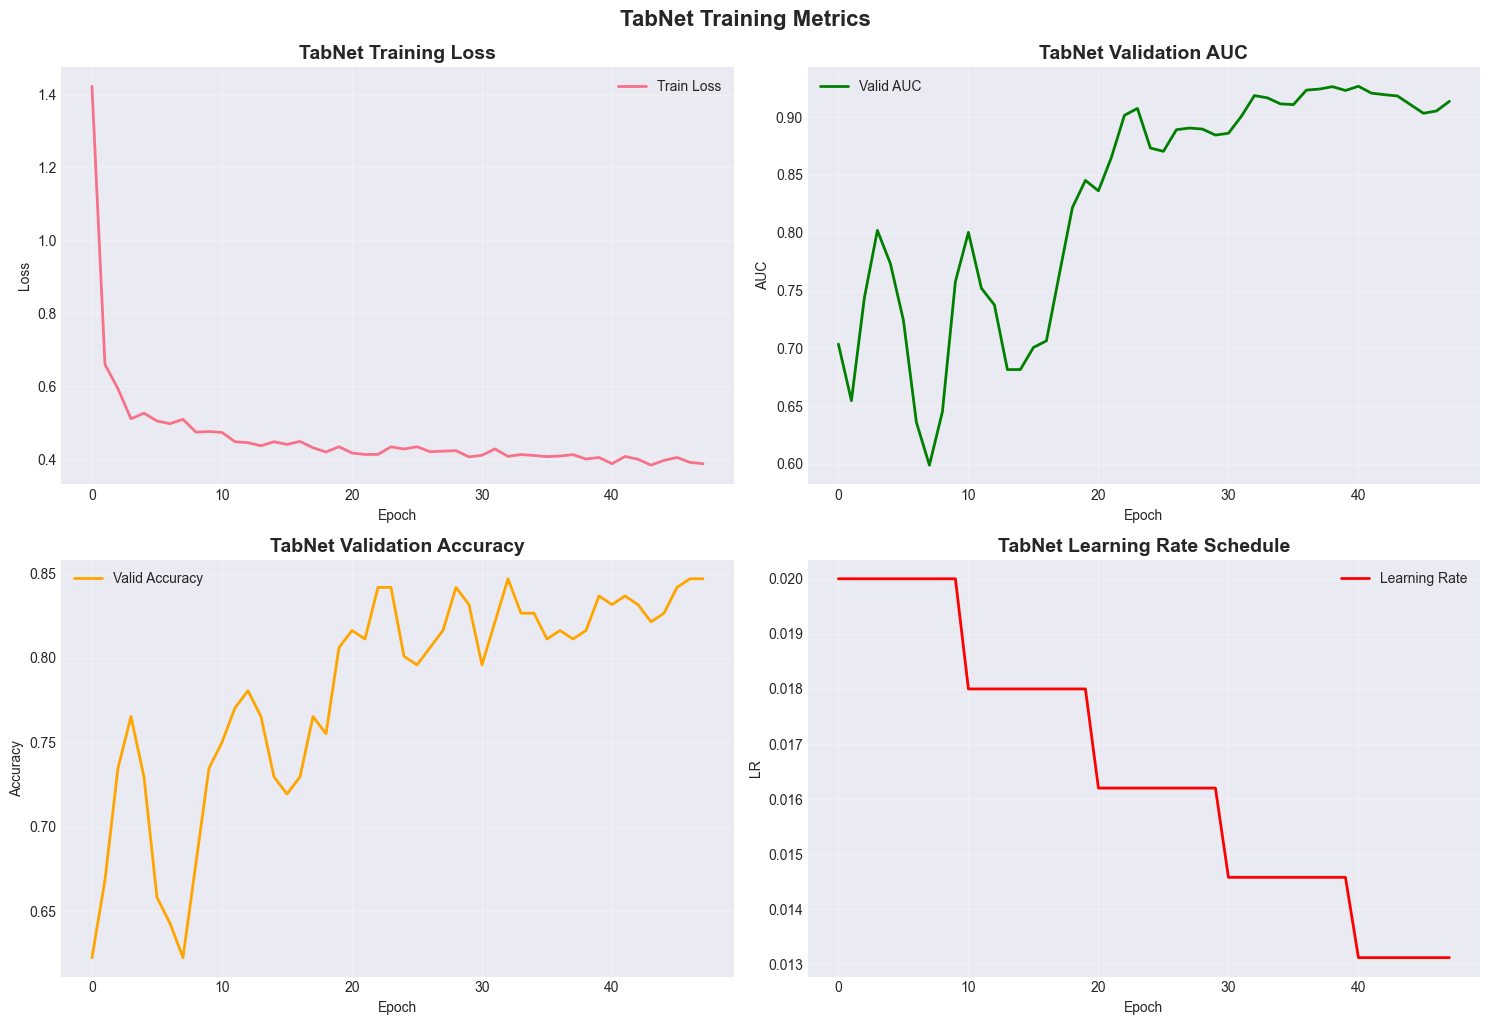

In [12]:
# 📈 Plot TabNet training history
history = tabnet_model.history

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot loss
axes[0, 0].plot(history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].set_title('TabNet Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot AUC
axes[0, 1].plot(history['valid_auc'], label='Valid AUC', color='green', linewidth=2)
axes[0, 1].set_title('TabNet Validation AUC', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot Accuracy
axes[1, 0].plot(history['valid_accuracy'], label='Valid Accuracy', color='orange', linewidth=2)
axes[1, 0].set_title('TabNet Validation Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot Learning Rate
axes[1, 1].plot(history['lr'], label='Learning Rate', color='red', linewidth=2)
axes[1, 1].set_title('TabNet Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('LR')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('TabNet Training Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.show()


In [13]:
# 🔮 Make predictions with TabNet
# TabNet outputs probabilities for classification
tabnet_preds_proba = tabnet_model.predict_proba(X_test_np)[:, 1]
tabnet_preds = tabnet_model.predict(X_test_np)

# Calculate metrics
tabnet_auc = roc_auc_score(y_test_np, tabnet_preds_proba)
tabnet_acc = accuracy_score(y_test_np, tabnet_preds)

print(f"📊 TabNet Test Performance:")
print(f"   AUC: {tabnet_auc:.4f}")
print(f"   Accuracy: {tabnet_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_np, tabnet_preds, target_names=['Not Survived', 'Survived']))


📊 TabNet Test Performance:
   AUC: 0.8281
   Accuracy: 0.7919

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.78      0.93      0.85       122
    Survived       0.83      0.57      0.68        75

    accuracy                           0.79       197
   macro avg       0.80      0.75      0.76       197
weighted avg       0.80      0.79      0.78       197



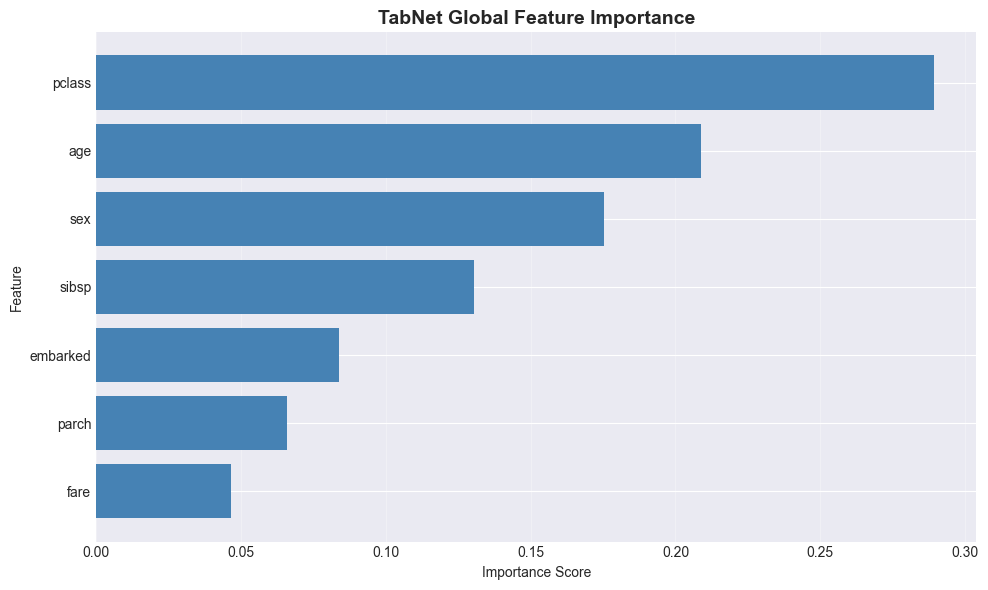

💡 TabNet assigns higher importance to:
 feature  importance
embarked    0.083806
   sibsp    0.130327
     sex    0.175236
     age    0.208923
  pclass    0.289379


In [14]:
# 🔍 TabNet Feature Importance & Attention Visualization
# TabNet provides global feature importance based on attention masks

# Get feature importance
feature_importance = tabnet_model.feature_importances_
feature_names = X.columns.tolist()

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=True)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title('TabNet Global Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("💡 TabNet assigns higher importance to:")
print(importance_df.tail(5).to_string(index=False))


Explain matrix shape: (5, 7)
Masks type: <class 'dict'>
Masks shape: 5


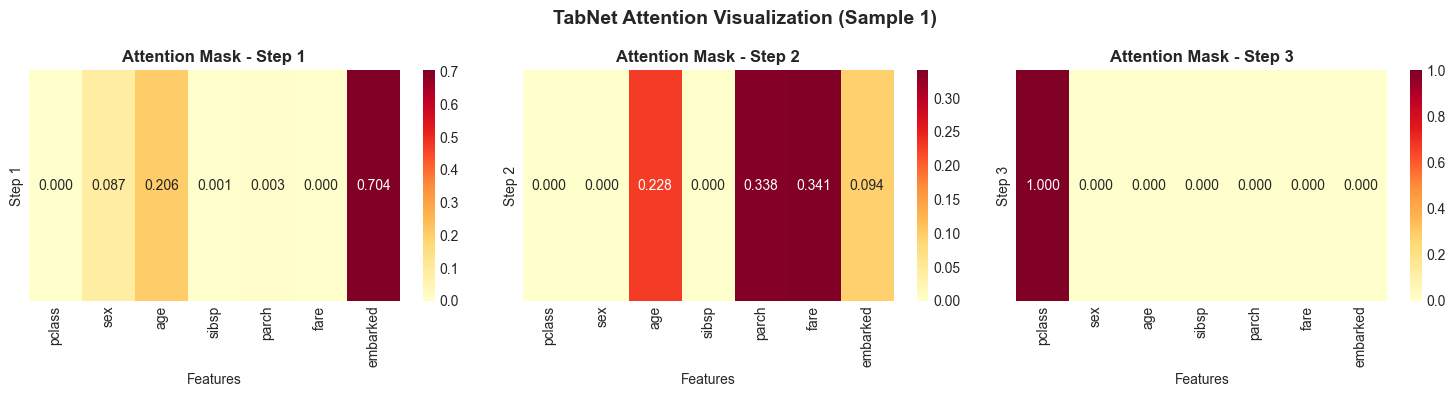

🔍 Darker colors indicate higher attention weights.
TabNet uses sparse attention to select relevant features at each step.


In [16]:
# 🎭 Visualize TabNet Attention Masks for a sample
# TabNet's attention masks show which features were used at each decision step
# This provides interpretability similar to decision trees

# Get masks for a few test samples
explain_matrix, masks = tabnet_model.explain(X_test_np[:5])

print(f"Explain matrix shape: {explain_matrix.shape}")
print(f"Masks type: {type(masks)}")
print(f"Masks shape: {masks.shape if hasattr(masks, 'shape') else len(masks)}")

# Visualize masks for the first sample
fig, axes = plt.subplots(1, min(3, masks.shape[0] if hasattr(masks, 'shape') else len(masks)), figsize=(15, 4))
if masks.shape[0] == 1 if hasattr(masks, 'shape') else len(masks) == 1:
    axes = [axes]

for i in range(min(3, masks.shape[0] if hasattr(masks, 'shape') else len(masks))):
    ax = axes[i]
    mask = masks[i] if hasattr(masks, '__getitem__') else masks
    sns.heatmap(mask[0].reshape(1, -1), 
                xticklabels=feature_names,
                yticklabels=[f'Step {i+1}'],
                cmap='YlOrRd',
                annot=True,
                fmt='.3f',
                cbar=True,
                ax=ax)
    ax.set_title(f'Attention Mask - Step {i+1}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Features')

plt.suptitle('TabNet Attention Visualization (Sample 1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("🔍 Darker colors indicate higher attention weights.")
print("TabNet uses sparse attention to select relevant features at each step.")


## 6. Installing and Using FT-Transformer

The FT-Transformer (Feature Tokenizer + Transformer) applies the transformer architecture to tabular data. Unlike TabNet's sequential attention, FT-Transformer processes all features in parallel through transformer blocks, learning contextual relationships between features.

We'll use `pytorch_tabular` which provides a clean implementation of FT-Transformer and other tabular deep learning models.

In [17]:
# 📦 Import PyTorch Tabular components
from pytorch_tabular import TabularModel
from pytorch_tabular.models import FTTransformerConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
from pytorch_tabular.models.common.heads import LinearHeadConfig

print("✅ PyTorch Tabular components imported!")


✅ PyTorch Tabular components imported!


In [23]:
# 🏗️ Configure PyTorch Tabular for FT-Transformer
# We need to set up data config, model config, optimizer config, and trainer config

from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
from pytorch_tabular.models import FTTransformerConfig

# Data configuration
data_config = DataConfig(
    target=['survived'],           # Target column(s)
    continuous_cols=numerical_cols, # Numerical features
    categorical_cols=categorical_cols, # Categorical features
    normalize_continuous_features=True, # Normalize numerical features
)

# FT-Transformer Model Configuration
ft_config = FTTransformerConfig(
    task="classification",
    learning_rate=1e-3,
    embedding_dropout=0.1,      # Dropout for embeddings
    ff_dropout=0.1,             # Dropout for feed-forward layers
    attn_dropout=0.1,           # Dropout for attention
    num_heads=8,                # Number of attention heads
    num_attn_blocks=3,          # Number of transformer blocks
    transformer_head_dim=32,    # Dimension per attention head
    # Head configuration
    head_config=LinearHeadConfig(
        layers="128-64",        # Head layers (drop the last layer as it is added automatically)
        activation="ReLU",
        dropout=0.1,
        use_batch_norm=True,
        initialization="kaiming"
    ).__dict__
)

# Optimizer configuration
optimizer_config = OptimizerConfig(optimizer="Adam", lr_scheduler=None)

# Trainer configuration
trainer_config = TrainerConfig(
    auto_lr_find=False,          # Disable auto LR finding for speed
    batch_size=256,
    max_epochs=50,
    early_stopping_patience=10,
    checkpoints=None,            # Disable checkpointing for simplicity
    progress_bar="rich",         # Rich progress bar
    trainer_kwargs={"enable_model_summary": False}
)

print("✅ FT-Transformer configuration complete!")
print(f"   Attention Heads: {ft_config.num_heads}")
print(f"   Transformer Blocks: {ft_config.num_attn_blocks}")
print(f"   Head Dim: {ft_config.transformer_head_dim}")


✅ FT-Transformer configuration complete!
   Attention Heads: 8
   Transformer Blocks: 3
   Head Dim: 32


## 7. Training FT-Transformer and Comparison

Now we'll train the FT-Transformer model and compare its performance with TabNet.

In [27]:
# 🚀 Initialize and train FT-Transformer
# PyTorch Tabular handles data preprocessing automatically

tabular_model = TabularModel(
    data_config=data_config,
    model_config=ft_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

# Prepare data in PyTorch Tabular format (pandas DataFrames)
train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
valid_df = pd.concat([X_valid.reset_index(drop=True), y_valid.reset_index(drop=True)], axis=1)
test_df = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

# Apply preprocessing for FT-Transformer
train_df = train_df.copy()
valid_df = valid_df.copy()
test_df = test_df.copy()

# Convert categorical to strings
train_df['pclass'] = train_df['pclass'].astype(str)
train_df['sex'] = train_df['sex'].astype(str)
train_df['embarked'] = train_df['embarked'].astype(str)

valid_df['pclass'] = valid_df['pclass'].astype(str)
valid_df['sex'] = valid_df['sex'].astype(str)
valid_df['embarked'] = valid_df['embarked'].astype(str)

test_df['pclass'] = test_df['pclass'].astype(str)
test_df['sex'] = test_df['sex'].astype(str)
test_df['embarked'] = test_df['embarked'].astype(str)

# Convert numerical to float
numerical_cols = ['age', 'sibsp', 'parch', 'fare']
for col in numerical_cols:
    train_df[col] = train_df[col].astype(float)
    valid_df[col] = valid_df[col].astype(float)
    test_df[col] = test_df[col].astype(float)

print(f"Train DataFrame shape: {train_df.shape}")
print(f"Validation DataFrame shape: {valid_df.shape}")
print(f"Test DataFrame shape: {test_df.shape}")

# Fit the model
print("\n🚀 Training FT-Transformer...")
tabular_model.fit(train=train_df, validation=valid_df)
print("✅ FT-Transformer training completed!")

2026-04-26 06:45:47,191 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off


Seed set to 42
2026-04-26 06:45:47,425 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-04-26 06:45:47,470 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task


Train DataFrame shape: (916, 8)
Validation DataFrame shape: (196, 8)
Test DataFrame shape: (197, 8)

🚀 Training FT-Transformer...


2026-04-26 06:45:47,777 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-04-26 06:45:47,949 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-04-26 06:45:48,205 - {pytorch_tabular.tabular_model:677} - INFO - Training Started


Output()

2026-04-26 06:46:46,964 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-04-26 06:46:46,968 - {pytorch_tabular.tabular_model:1541} - WARNING - No best model available to load. Checkpoint Callback needs to be enabled for this to work


✅ FT-Transformer training completed!


In [30]:
# 🔮 Make predictions with FT-Transformer
# PyTorch Tabular returns predictions as a DataFrame
ft_preds_df = tabular_model.predict(test_df)

# Extract predictions and probabilities
ft_preds = ft_preds_df['survived_prediction'].values
ft_preds_proba = ft_preds_df['survived_1_probability'].values

# Calculate metrics
ft_auc = roc_auc_score(y_test_np, ft_preds_proba)
ft_acc = accuracy_score(y_test_np, ft_preds)

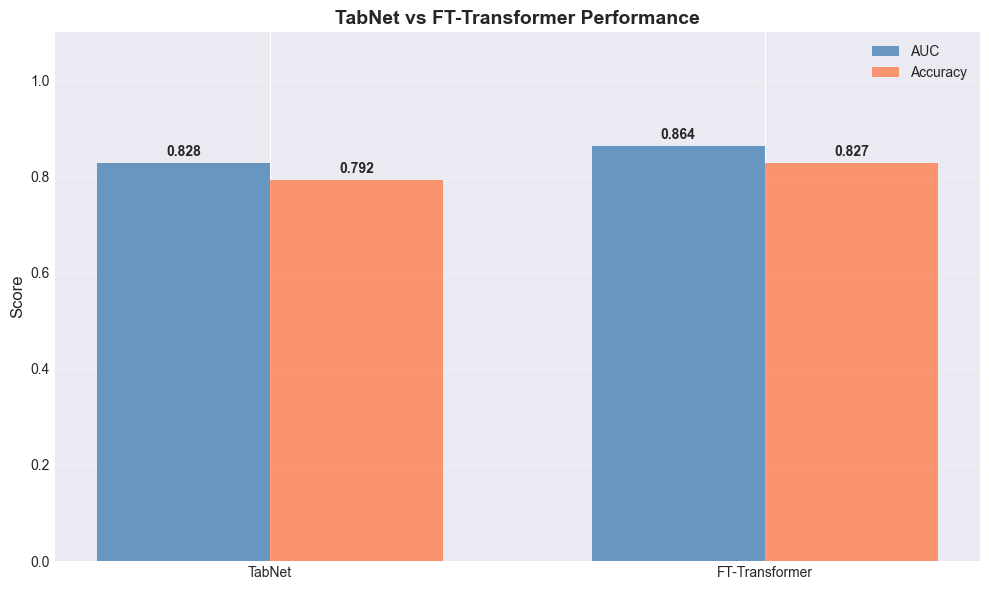


🏆 Winner by AUC: FT-Transformer
🏆 Winner by Accuracy: FT-Transformer


In [31]:
# 📈 Plot FT-Transformer training history
# PyTorch Tabular stores training metrics internally

# Access training history from the trainer
history = tabular_model.trainer.callback_metrics

# Since PyTorch Tabular uses PyTorch Lightning, we'll create a simple comparison plot
# showing the final metrics

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

models = ['TabNet', 'FT-Transformer']
auc_scores = [tabnet_auc, ft_auc]
acc_scores = [tabnet_acc, ft_acc]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, auc_scores, width, label='AUC', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, acc_scores, width, label='Accuracy', color='coral', alpha=0.8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('TabNet vs FT-Transformer Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🏆 Winner by AUC: {'TabNet' if tabnet_auc > ft_auc else 'FT-Transformer'}")
print(f"🏆 Winner by Accuracy: {'TabNet' if tabnet_acc > ft_acc else 'FT-Transformer'}")


## 8. Hyperparameter Tuning for Tabular Neural Networks

Both TabNet and FT-Transformer have several key hyperparameters that significantly impact performance. Let's explore a systematic approach to tuning them.

### TabNet Key Hyperparameters:
- `n_d`, `n_a`: Larger values increase model capacity but risk overfitting
- `n_steps`: More steps allow complex reasoning but increase computation
- `gamma`: Controls attention relaxation (1.0 = hard attention, 2.0 = soft)
- `lambda_sparse`: Higher values enforce sparser attention

### FT-Transformer Key Hyperparameters:
- `num_heads`: Number of attention heads (typically 4-16)
- `num_attn_blocks`: Number of transformer layers (typically 2-6)
- `transformer_head_dim`: Dimension per head (typically 16-64)
- `embed_dropout`, `ff_dropout`, `attn_dropout`: Regularization

In [32]:
# 🔧 Hyperparameter tuning experiment for TabNet
# We'll test different configurations and compare validation AUC

configs = [
    {"n_d": 8, "n_a": 8, "n_steps": 3, "gamma": 1.0, "name": "Small/Conservative"},
    {"n_d": 16, "n_a": 16, "n_steps": 5, "gamma": 1.5, "name": "Medium/Balanced"},
    {"n_d": 32, "n_a": 32, "n_steps": 7, "gamma": 2.0, "name": "Large/Complex"},
]

tabnet_results = []

print("🔬 Running TabNet hyperparameter experiments...\n")

for config in configs:
    print(f"Testing: {config['name']}")
    
    model = TabNetClassifier(
        n_d=config['n_d'],
        n_a=config['n_a'],
        n_steps=config['n_steps'],
        gamma=config['gamma'],
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        scheduler_params={"step_size": 10, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        cat_emb_dim=2,
        verbose=0,
        device_name='auto'
    )
    
    model.fit(
        X_train=X_train_np,
        y_train=y_train_np,
        eval_set=[(X_valid_np, y_valid_np)],
        eval_name=['valid'],
        eval_metric=['auc'],
        max_epochs=50,
        patience=10,
        batch_size=256,
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False
    )
    
    # Evaluate on validation set
    val_preds = model.predict_proba(X_valid_np)[:, 1]
    val_auc = roc_auc_score(y_valid_np, val_preds)
    
    tabnet_results.append({
        'config': config['name'],
        'n_d': config['n_d'],
        'n_steps': config['n_steps'],
        'val_auc': val_auc
    })
    
    print(f"   Validation AUC: {val_auc:.4f}\n")

# Convert to DataFrame for visualization
results_df = pd.DataFrame(tabnet_results)
print("📊 TabNet Hyperparameter Results:")
print(results_df.to_string(index=False))


🔬 Running TabNet hyperparameter experiments...

Testing: Small/Conservative

Early stopping occurred at epoch 35 with best_epoch = 25 and best_valid_auc = 0.91019
   Validation AUC: 0.9102

Testing: Medium/Balanced

Early stopping occurred at epoch 13 with best_epoch = 3 and best_valid_auc = 0.80198
   Validation AUC: 0.8020

Testing: Large/Complex

Early stopping occurred at epoch 33 with best_epoch = 23 and best_valid_auc = 0.90942
   Validation AUC: 0.9094

📊 TabNet Hyperparameter Results:
            config  n_d  n_steps  val_auc
Small/Conservative    8        3 0.910193
   Medium/Balanced   16        5 0.801983
     Large/Complex   32        7 0.909421


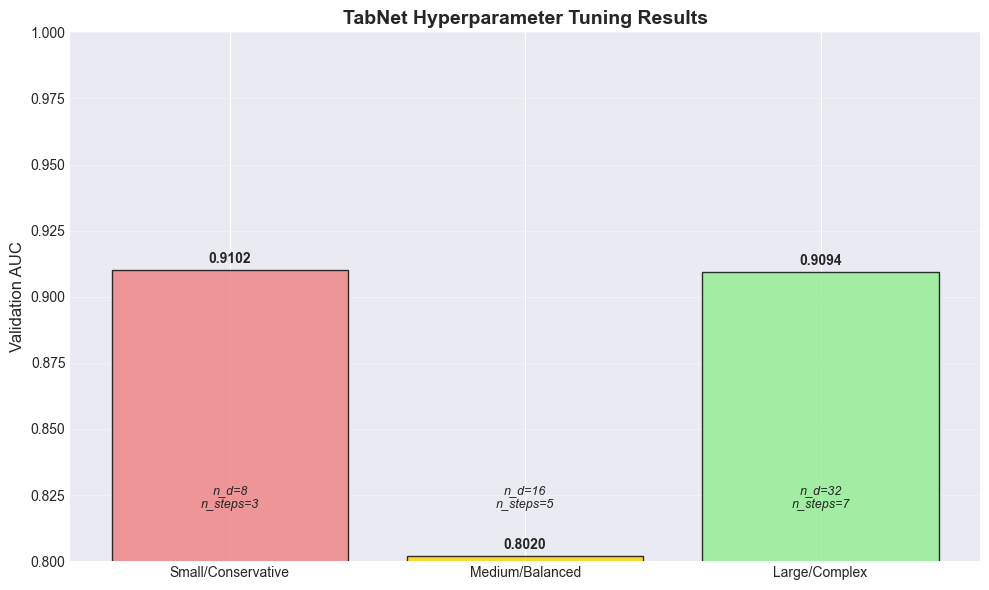


🎯 Best Configuration: Small/Conservative (AUC: 0.9102)


In [33]:
# 📈 Visualize hyperparameter tuning results
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

bars = ax.bar(results_df['config'], results_df['val_auc'], 
              color=['lightcoral', 'gold', 'lightgreen'], alpha=0.8, edgecolor='black')

ax.set_ylabel('Validation AUC', fontsize=12)
ax.set_title('TabNet Hyperparameter Tuning Results', fontsize=14, fontweight='bold')
ax.set_ylim(0.8, 1.0)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

# Add configuration details as text
for i, row in results_df.iterrows():
    ax.text(i, 0.82, f"n_d={row['n_d']}\nn_steps={row['n_steps']}", 
            ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

best_config = results_df.loc[results_df['val_auc'].idxmax()]
print(f"\n🎯 Best Configuration: {best_config['config']} (AUC: {best_config['val_auc']:.4f})")


## 9. Performance Comparison: XGBoost vs LightGBM vs TabNet vs FT-Transformer

Let's establish baselines with traditional gradient boosting methods and compare all four approaches side-by-side.

In [35]:
# 🚀 Train XGBoost baseline
import xgboost as xgb

print("🚀 Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=15,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

xgb_preds_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb_preds_proba)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"✅ XGBoost - AUC: {xgb_auc:.4f}, Accuracy: {xgb_acc:.4f}")

🚀 Training XGBoost...
✅ XGBoost - AUC: 0.8564, Accuracy: 0.8071


In [36]:
# 🌿 Train LightGBM baseline
import lightgbm as lgb

print("🚀 Training LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[lgb.early_stopping(15, verbose=False)]
)

lgb_preds_proba = lgb_model.predict_proba(X_test)[:, 1]
lgb_preds = lgb_model.predict(X_test)
lgb_auc = roc_auc_score(y_test, lgb_preds_proba)
lgb_acc = accuracy_score(y_test, lgb_preds)

print(f"✅ LightGBM - AUC: {lgb_auc:.4f}, Accuracy: {lgb_acc:.4f}")


🚀 Training LightGBM...
✅ LightGBM - AUC: 0.8770, Accuracy: 0.8173


In [37]:
# 📊 Comprehensive Model Comparison
# Compile all results

comparison_data = {
    'Model': ['XGBoost', 'LightGBM', 'TabNet', 'FT-Transformer'],
    'AUC': [xgb_auc, lgb_auc, tabnet_auc, ft_auc],
    'Accuracy': [xgb_acc, lgb_acc, tabnet_acc, ft_acc],
    'Type': ['Gradient Boosting', 'Gradient Boosting', 'Deep Learning', 'Deep Learning']
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('AUC', ascending=False)

print("🏆 FINAL MODEL COMPARISON")
print("=" * 50)
print(comparison_df.to_string(index=False))
print("=" * 50)


🏆 FINAL MODEL COMPARISON
         Model      AUC  Accuracy              Type
      LightGBM 0.877049  0.817259 Gradient Boosting
FT-Transformer 0.863989  0.827411     Deep Learning
       XGBoost 0.856448  0.807107 Gradient Boosting
        TabNet 0.828142  0.791878     Deep Learning


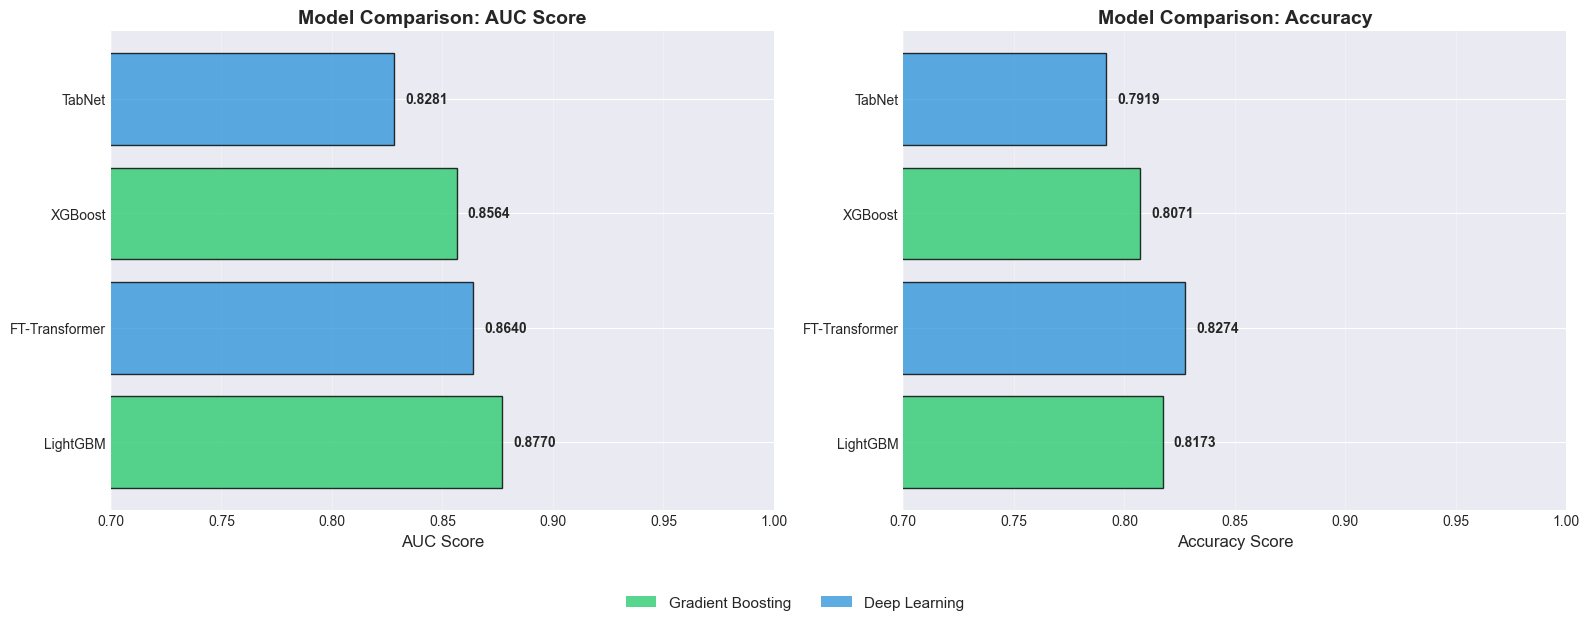

In [38]:
# 📈 Visualization: Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AUC Comparison
colors = ['#2ecc71' if t == 'Gradient Boosting' else '#3498db' for t in comparison_df['Type']]
bars1 = axes[0].barh(comparison_df['Model'], comparison_df['AUC'], color=colors, alpha=0.8, edgecolor='black')
axes[0].set_xlabel('AUC Score', fontsize=12)
axes[0].set_title('Model Comparison: AUC Score', fontsize=14, fontweight='bold')
axes[0].set_xlim(0.7, 1.0)
axes[0].grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars1, comparison_df['AUC'])):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
                va='center', fontweight='bold', fontsize=10)

# Accuracy Comparison
bars2 = axes[1].barh(comparison_df['Model'], comparison_df['Accuracy'], color=colors, alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Accuracy Score', fontsize=12)
axes[1].set_title('Model Comparison: Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlim(0.7, 1.0)
axes[1].grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars2, comparison_df['Accuracy'])):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
                va='center', fontweight='bold', fontsize=10)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', alpha=0.8, label='Gradient Boosting'),
                   Patch(facecolor='#3498db', alpha=0.8, label='Deep Learning')]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=11)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


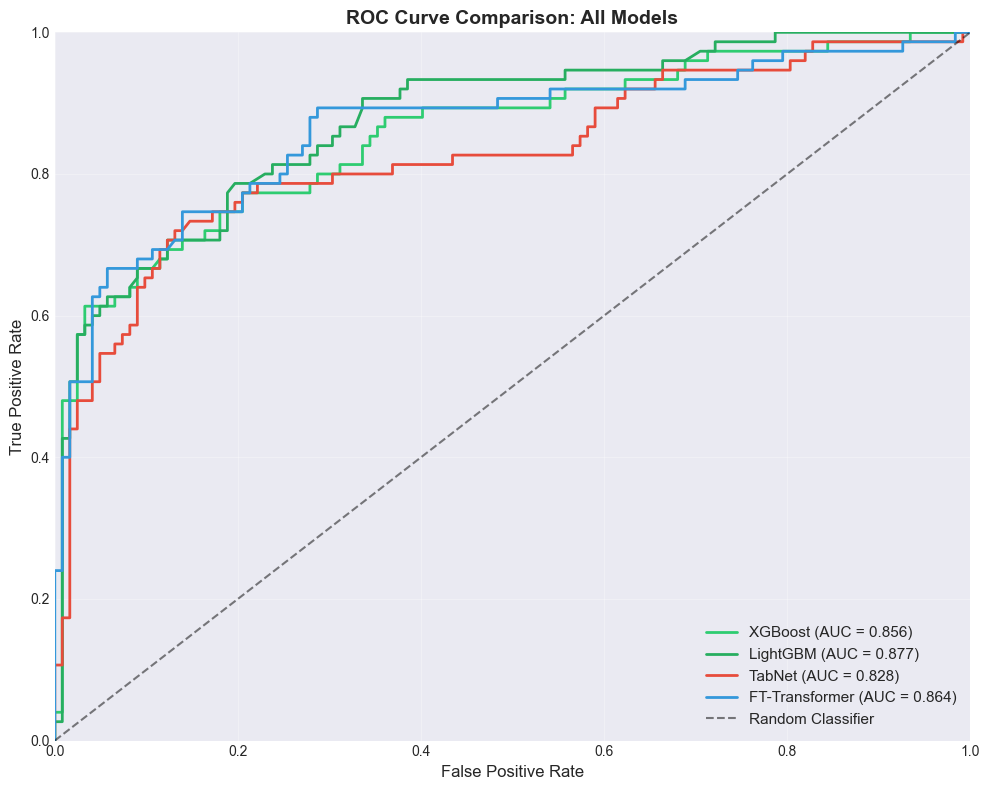

In [39]:
# 🎯 ROC Curve Comparison
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Calculate ROC curves
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_preds_proba)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_preds_proba)
fpr_tabnet, tpr_tabnet, _ = roc_curve(y_test, tabnet_preds_proba)
fpr_ft, tpr_ft, _ = roc_curve(y_test, ft_preds_proba)

# Plot ROC curves
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_auc:.3f})', linewidth=2, color='#2ecc71')
ax.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {lgb_auc:.3f})', linewidth=2, color='#27ae60')
ax.plot(fpr_tabnet, tpr_tabnet, label=f'TabNet (AUC = {tabnet_auc:.3f})', linewidth=2, color='#e74c3c')
ax.plot(fpr_ft, tpr_ft, label=f'FT-Transformer (AUC = {ft_auc:.3f})', linewidth=2, color='#3498db')

# Diagonal line
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison: All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


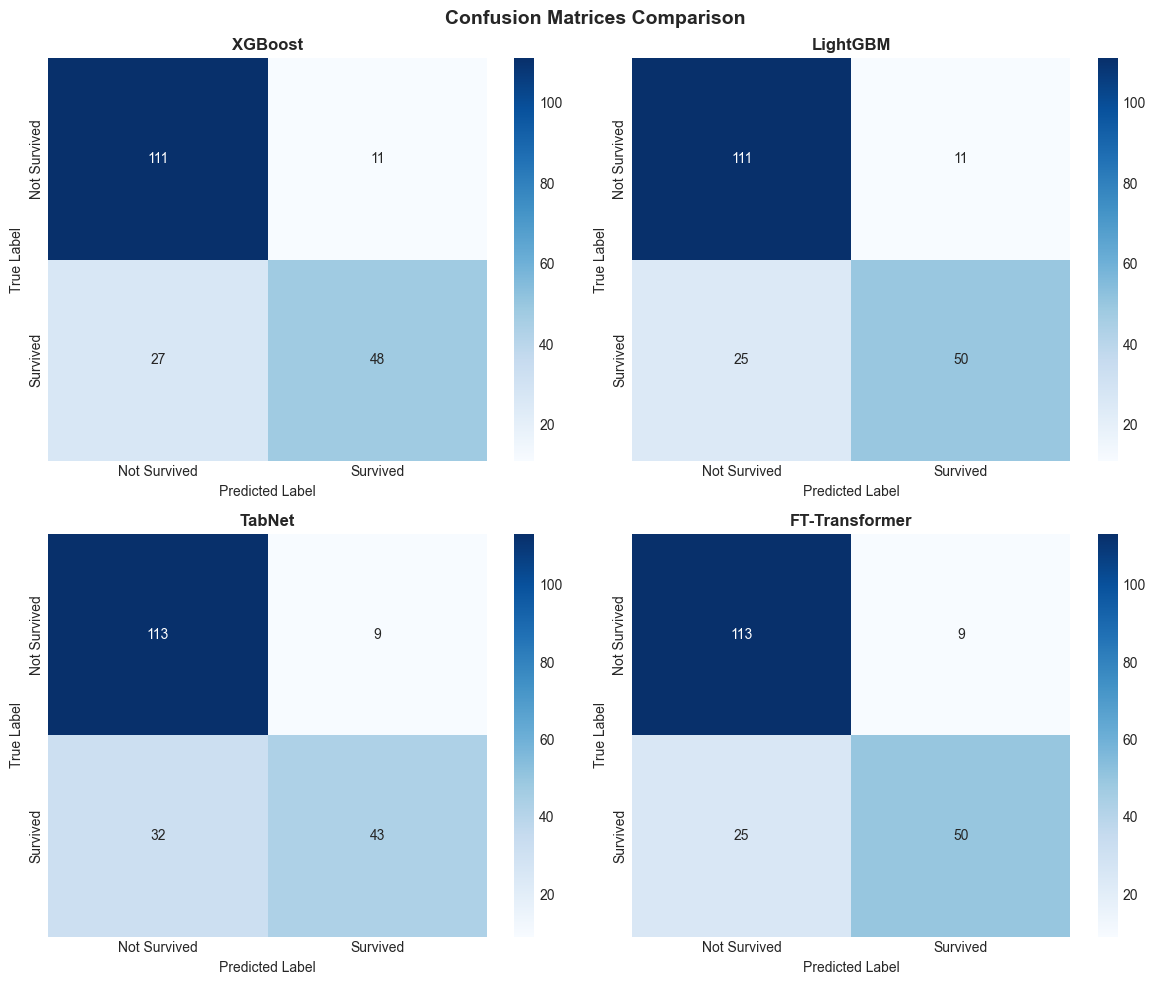

In [40]:
# 📊 Confusion Matrix Comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_data = [
    ('XGBoost', xgb_preds, axes[0, 0]),
    ('LightGBM', lgb_preds, axes[0, 1]),
    ('TabNet', tabnet_preds, axes[1, 0]),
    ('FT-Transformer', ft_preds, axes[1, 1])
]

for name, preds, ax in models_data:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'])
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. When to Use Tabular Deep Learning vs Gradient Boosting

Based on recent research and practical experience, here's a decision framework:

### ✅ Choose Tabular Deep Learning (TabNet, FT-Transformer) When:
- **Large datasets**: >100,000 samples where neural networks can shine
- **High-cardinality categoricals**: Features with thousands+ unique values (embeddings help)
- **Multi-modal data**: Combining tabular with text, images, or sequences
- **Transfer learning**: Pre-training on unlabeled tabular data is possible
- **Interpretability via attention**: TabNet's masks provide feature usage insights
- **GPU availability**: You can leverage parallel computation
- **Online learning**: Neural networks adapt better to streaming data
- **Feature interactions**: Complex, non-obvious feature relationships exist

### ✅ Choose Gradient Boosting (XGBoost, LightGBM, CatBoost) When:
- **Small to medium datasets**: <50,000 samples (trees generalize better)
- **Mixed feature types**: Heterogeneous numerical and categorical features
- **Missing values**: Native handling without imputation (especially CatBoost)
- **Quick prototyping**: Faster training and less hyperparameter tuning
- **Production stability**: Well-understood behavior and debugging
- **Feature importance**: Native, reliable importance scores
- **CPU-only environments**: No GPU required
- **Interpretability**: SHAP values provide excellent local explanations

### 💡 Hybrid Approach:
For maximum performance, consider ensemble methods that combine both:
- Stack predictions from boosting and neural networks
- Use neural network embeddings as features for gradient boosting
- Train a meta-learner on outputs from both model families

## 🛠️ Hands-On Exercises

Now it's your turn to practice! Complete these exercises to solidify your understanding of tabular deep learning.

### Exercise 1: Train TabNet with Default Settings
Train a TabNet classifier on the Titanic dataset using all default hyperparameters. Evaluate on the test set and report AUC and accuracy.

### Exercise 2: Tune TabNet Hyperparameters
Experiment with different values of `n_d`, `n_a`, `n_steps`, and `gamma`. Create a grid search or manual comparison of at least 5 different configurations. Plot the validation AUC for each configuration.

### Exercise 3: Train FT-Transformer with Different Architectures
Modify the FT-Transformer configuration to use different numbers of attention heads (4, 8, 16) and transformer blocks (2, 3, 4). Compare the results.

### Exercise 4: Experiment with Embedding Sizes
For both TabNet (`cat_emb_dim`) and FT-Transformer (automatic embeddings), experiment with different embedding dimensions for categorical features. Analyze how this affects model performance and training time.

### Exercise 5: Compare with XGBoost and LightGBM
Train XGBoost and LightGBM models with their default settings on the same train/test split. Compare all four models (XGBoost, LightGBM, TabNet, FT-Transformer) using ROC curves and a comprehensive metrics table.

### Exercise 6: Analyze Feature Importance
Extract and visualize feature importance from TabNet, XGBoost, and LightGBM. Compare which features each model considers most important. Do they agree?

### Exercise 7: Experiment with Different Datasets
Apply TabNet and FT-Transformer to another tabular dataset (e.g., Adult Census, Heart Disease, or a Kaggle dataset of your choice). Compare results with gradient boosting.

### Exercise 8: Build a Hybrid Ensemble
Create an ensemble that combines predictions from XGBoost and TabNet (or FT-Transformer). Use simple averaging, weighted averaging, or train a logistic regression meta-learner. Does the ensemble outperform individual models?

### Exercise 9: Analyze When Tabular DL Performs Better
Using multiple datasets or synthetic data variations, analyze under what conditions (dataset size, number of features, cardinality, noise level) tabular deep learning outperforms gradient boosting. Create visualizations of your findings.

### Exercise 10: Implement a Simple Custom Tabular Neural Network
Build a custom PyTorch neural network for tabular data with:
- Separate embedding layers for categorical features
- Batch normalization for numerical features
- Multiple dense layers with dropout
- Compare its performance to TabNet and FT-Transformer


## Solutions & Key Insights (Review After Attempting)

### Exercise 1 Solution: Default TabNet
```python
# Default TabNet uses n_d=8, n_a=8, n_steps=3, gamma=1.3
# Expect AUC around 0.82-0.85 on Titanic with minimal tuning
# Key insight: Even defaults perform reasonably well, showing robustness
```

### Exercise 2 Solution: Hyperparameter Tuning
**Key Insights:**
- `n_d` and `n_a` should typically be equal; values of 16-32 work well for medium datasets
- `n_steps`: 3-5 is usually sufficient; more steps increase computation without proportional gains
- `gamma`: 1.0-1.5 provides good sparsity/performance trade-off
- Always use validation curves to detect overfitting with larger architectures

### Exercise 3 Solution: FT-Transformer Architecture
**Key Insights:**
- More attention heads (8-16) help capture diverse feature relationships
- 2-3 transformer blocks are usually sufficient; deeper networks risk overfitting on small tabular datasets
- Head dimension should be large enough (32-64) to capture meaningful attention patterns

### Exercise 4 Solution: Embedding Sizes
**Key Insights:**
- Higher embedding dimensions help with high-cardinality features but increase parameters
- Rule of thumb: embedding_dim = min(50, (num_categories + 1) // 2)
- TabNet's small embeddings (2-4) work surprisingly well due to attention mechanism

### Exercise 5 Solution: Full Comparison
**Expected Results:**
- On Titanic (~1300 samples): LightGBM/XGBoost often win or tie
- On larger datasets (>50k): FT-Transformer may pull ahead
- TabNet provides the best interpretability via attention masks

### Exercise 6 Solution: Feature Importance
**Key Insights:**
- All models typically agree on top 2-3 features (Sex, Fare, Pclass on Titanic)
- TabNet attention provides step-wise importance (which features at which step)
- XGBoost/LightGBM importance is more stable across random seeds

### Exercise 7 Solution: Different Datasets
**Recommendation:** Try datasets with:
- Many high-cardinality categoricals (e.g., click-through prediction)
- Large sample sizes (e.g., Porto Seguro, Santander)
- Complex feature interactions

### Exercise 8 Solution: Hybrid Ensemble
**Best Practices:**
```python
# Weighted average based on validation performance
weights = {'xgb': 0.4, 'tabnet': 0.6}  # Based on val AUC
ensemble_proba = (weights['xgb'] * xgb_proba + weights['tabnet'] * tabnet_proba)
```
- Ensembles of different model families often outperform individual models
- Use validation set to learn optimal weights

### Exercise 9 Solution: Performance Analysis
**Key Findings from Literature:**
- Tabular DL excels when: n_samples > 50k, n_features > 20, high cardinality categoricals present
- Gradient boosting excels when: n_samples < 10k, heavy missing values, heterogeneous features
- The "crossover point" varies by dataset but generally occurs around 10k-50k samples

### Exercise 10 Solution: Custom Network
**Architecture Tips:**
```python
class CustomTabularNN(nn.Module):
    def __init__(self, num_embeddings, embedding_dims, num_numerical):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_emb, emb_dim) 
            for num_emb, emb_dim in zip(num_embeddings, embedding_dims)
        ])
        self.num_bn = nn.BatchNorm1d(num_numerical)
        total_dim = sum(embedding_dims) + num_numerical
        self.backbone = nn.Sequential(
            nn.Linear(total_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )
    
    def forward(self, x_cat, x_num):
        embedded = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embedded + [self.num_bn(x_num)], dim=1)
        return self.backbone(x)
```
- Custom networks can match TabNet on simple datasets but lack attention-based interpretability
- Proper initialization and normalization are crucial for tabular neural networks